# Lab 3 — Descriptive Statistics Assignment: Gym Membership Dataset

**School of Computer Science and Engineering (SOCSE) — RV University**

**Name:** _PRANAMYA K___________________________  **Roll No.:** 1RUA25CSE0336_______________  **Section:** ____G___

---

## Instructions

- This is a follow-up to Lab 3 (descriptive statistics on the student survey dataset). The same
  concepts — central tendency, dispersion, distribution shape, and visualization — are applied here
  to a **new dataset** describing gym members, so you can practice choosing the right
  statistic rather than remembering the answer from Lab 3.
-
- Every question below has an empty code cell (marked `# TODO`) for your solution, and most also   have a markdown cell marked **Your answer:** for a short written interpretation. Write your
  interpretation in your own words — a correct number with no explanation will not receive full  marks for questions that ask you to interpret.
- Run your notebook **top to bottom** (Kernel → Restart & Run All) before submitting, and make sure
  it completes with no errors.
-

### Learning objectives
By the end of this assignment you should be able to: compute and correctly choose between mean,
median, and mode; compute and interpret variance, standard deviation, and IQR; use skewness and
kurtosis to identify non-normal distributions; and build/interpret histograms, box plots, and scatter plots to support (or challenge) what the summary statistics suggest.

In [5]:
# --- Core libraries used throughout the notebook (provided — no changes needed) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 7
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.precision", 3)

print("Libraries loaded. Random seed set to", RANDOM_SEED)

Libraries loaded. Random seed set to 7


## Part 1 — The Dataset (provided, do not modify)

This dataset simulates **150 gym members**, with the same design idea as Lab 3: each numeric
feature is deliberately shaped differently, so no single statistic works well for all of them.

| Feature | Real-world meaning | Intended shape |
|---|---|---|
| `workout_duration_minutes` | Average length of a workout session | *(shape not disclosed — see Q7/Q8)* |
| `monthly_membership_fee_inr` | Monthly membership fee paid (₹) | *(shape not disclosed — see Q7/Q8)* |
| `attendance_percentage` | % of scheduled sessions actually attended | *(shape not disclosed — see Q7/Q8)* |
| `weekly_visit_count` | Number of gym visits per week | *(shape not disclosed — see Q7/Q8)* |
| `preferred_workout` | Favorite workout category | categorical |

Unlike Lab 3, the shapes are **not labeled** for you this time — figuring out which feature is
approximately normal, right-skewed, left-skewed, or bimodal (and *proving it* with statistics and
plots) is part of the assignment.

In [6]:
df=pd.read_csv("gym_members_synthetic.csv")
df.head(8)

,member_id,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count,preferred_workout
0,M001,69.7,1690.0,71.7,1.3,Cardio
1,M002,81.0,2450.0,86.2,2.2,Weights
2,M003,62.6,2190.0,89.0,5.1,CrossFit
3,M004,65.7,3170.0,79.6,5.4,Cardio
4,M005,49.3,1050.0,80.7,1.5,Weights
5,M006,39.1,1180.0,88.0,5.0,Weights
6,M007,52.3,800.0,81.3,2.1,Weights
7,M008,73.0,2630.0,82.3,5.5,Yoga


In [7]:
FEATURES = [
    "workout_duration_minutes",
    "monthly_membership_fee_inr",
    "attendance_percentage",
    "weekly_visit_count"
]

### Q1 (2 marks) — Initial exploration

In the code cell below: display the shape of `df`, the data type of each column (`.dtypes`), the
summary statistics of the numeric columns (`.describe()`), and check whether any values are
missing (`.isna().sum()`).

In [8]:
# TODO: Q1 — shape, dtypes, describe(), and missing-value check
# Q1 — Initial exploration

print("Shape of dataframe:")
print(df.shape)

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

print("\nMissing values:")
print(df.isna().sum())

Shape of dataframe:
(150, 6)

Data types:
member_id                         str
workout_duration_minutes      float64
monthly_membership_fee_inr    float64
attendance_percentage         float64
weekly_visit_count            float64
preferred_workout                 str
dtype: object

Summary statistics:
       workout_duration_minutes  monthly_membership_fee_inr  \
count                   150.000                     150.000   
mean                     54.618                    2283.067   
std                      11.397                     984.837   
min                      27.800                     800.000   
25%                      48.050                    1515.000   
50%                      54.350                    2030.000   
75%                      62.875                    2825.000   
max                      81.000                    6420.000   

       attendance_percentage  weekly_visit_count  
count                150.000             150.000  
mean                  84.

## Part 2 — Measures of Central Tendency

Recall from Lab 3: the **mean** uses every value and is efficient but outlier-sensitive; the
**median** only depends on the middle position and is robust to outliers; the **mode** is the most
frequent value and is most meaningful for categorical or discrete data.



In the code cell below, compute the **mean, median, and mode** of each of the four numeric features
in `FEATURES`, and separately the **mode** of `preferred_workout`. Present the four numeric results
as a single small table (a DataFrame is fine).

In [9]:
# TODO: Q2 — mean, median, mode for each numeric feature; mode of preferre
results = pd.DataFrame({
    "Mean": df[FEATURES].mean(),
    "Median": df[FEATURES].median(),
    "Mode": df[FEATURES].mode().iloc[0]
})

print("Mean, Median and Mode of numerical features:")
display(results)

print("\nMode of preferred_workout:")
print(df["preferred_workout"].mode().iloc[0])

Mean, Median and Mode of numerical features:


,Mean,Median,Mode
workout_duration_minutes,54.618,54.35,57.8
monthly_membership_fee_inr,2283.067,2030.00,1440.0
attendance_percentage,84.210,85.10,85.1
weekly_visit_count,3.337,2.40,2.3



Mode of preferred_workout:
Cardio


### Q3  — Written interpretation

Looking at your table from Q2: for which numeric feature(s) do the mean and median differ the most
(in relative, not absolute, terms)? What does that gap suggest about the shape of that feature's
distribution, and in which direction would you expect its tail to stretch? You have not plotted
anything yet — base your answer only on the numbers.

**Your answer:**

_(write here)_

### Q4 (4 marks) — The outlier effect

Suppose one gym member signs up for a **founder's lifetime membership** and pays a one-time fee of
**₹80,000** that month. In the code cell below: make a **copy** of `df` (do not modify the original
`df`), add this one hypothetical value to `monthly_membership_fee_inr` in the copy, and print the
mean and median of that column **before and after** adding it.

Then, in the markdown cell below, explain in 2–3 sentences why the mean and median reacted
differently, referencing what you know about how each statistic is calculated.

In [10]:
# TODO: Q4 — add the ₹80,000 outlier to a COPY of df, compare mean/median before vs. after

df_outlier = df.copy()

# Mean and median before adding the outlier
print("Before adding outlier:")
print("Mean:", df_outlier["monthly_membership_fee_inr"].mean())
print("Median:", df_outlier["monthly_membership_fee_inr"].median())

# Add the hypothetical ₹80,000 value
df_outlier.loc[len(df_outlier), "monthly_membership_fee_inr"] = 80000

# Mean and median after adding the outlier
print("\nAfter adding outlier:")
print("Mean:", df_outlier["monthly_membership_fee_inr"].mean())
print("Median:", df_outlier["monthly_membership_fee_inr"].median())

Before adding outlier:
Mean: 2283.0666666666666
Median: 2030.0

After adding outlier:
Mean: 2797.748344370861
Median: 2030.0


**Your answer:**
The mean changes significantly because it is calculated using the sum of all values divided by the number of values, so a very large outlier directly increases it. The median changes little or may not change because it depends only on the middle value after sorting the data, making it less affected by extreme values.

## Part 3 — Measures of Dispersion

### Q5 (5 marks) — Manual calculation

Without using `.var()`, `.std()`, `np.var()`, or `np.std()`, calculate the **variance** and
**standard deviation** of `workout_duration_minutes` by hand, following the sample-variance formula:

$$
\text{variance} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})^2}{n-1}
\qquad\qquad
\text{standard deviation} = \sqrt{\text{variance}}
$$

Work through it step by step (compute the mean, then the deviations, then the squared deviations,
then the variance, then the standard deviation — printing each intermediate result), and then
verify your manual answer matches `np.var(..., ddof=1)` and `np.std(..., ddof=1)`.

In [11]:
# TODO: Q5 — manual variance & standard deviation for workout_duration_min
x = df["workout_duration_minutes"]

# Step 1: Calculate the mean manually
mean = x.sum() / len(x)
print("Step 1 - Mean:")
print(mean)

# Step 2: Calculate deviations from the mean
deviations = x - mean
print("\nStep 2 - Deviations:")
print(deviations)

# Step 3: Calculate squared deviations
squared_deviations = deviations ** 2
print("\nStep 3 - Squared deviations:")
print(squared_deviations)

# Step 4: Calculate sample variance
# Sample variance = sum of squared deviations / (n - 1)
n = len(x)
variance = squared_deviations.sum() / (n - 1)
print("\nStep 4 - Sample Variance:")
print(variance)

# Step 5: Calculate sample standard deviation
standard_deviation = variance ** 0.5
print("\nStep 5 - Sample Standard Deviation:")
print(standard_deviation)

# Verification
print("\nVerification using NumPy:")
print("np.var(ddof=1):", np.var(x, ddof=1))
print("np.std(ddof=1):", np.std(x, ddof=1))


Step 1 - Mean:
54.618

Step 2 - Deviations:
0      15.082
1      26.382
2       7.982
3      11.082
4      -5.318
        ...  
145     4.582
146    -1.818
147    11.482
148    25.482
149     8.582
Name: workout_duration_minutes, Length: 150, dtype: float64

Step 3 - Squared deviations:
0      227.467
1      696.010
2       63.712
3      122.811
4       28.281
        ...   
145     20.995
146      3.305
147    131.836
148    649.332
149     73.651
Name: workout_duration_minutes, Length: 150, dtype: float64

Step 4 - Sample Variance:
129.89786174496643

Step 5 - Sample Standard Deviation:
11.397274312087362

Verification using NumPy:
np.var(ddof=1): 129.89786174496643
np.std(ddof=1): 11.397274312087362


### Q6 — IQR and outlier detection

For **each** of the four numeric features: compute Q1, Q3, and the IQR; compute the lower bound
(`Q1 - 1.5*IQR`) and upper bound (`Q3 + 1.5*IQR`); and count how many values fall outside those
bounds (i.e., how many outliers each feature has by this rule).

**Your answer (2–3 sentences):** Which feature has the most outliers by this rule? Suggest one
real-world reason a gym dataset might realistically show that pattern for that feature.

_(write here)_

In [13]:
# TODO: Q6 — Q1, Q3, IQR, bounds, and outlier count for each of the four numeric feature
iqr_results = []

for feature in FEATURES:
    # Calculate Q1 and Q3
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Calculate lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = ((df[feature] < lower_bound) | 
                (df[feature] > upper_bound)).sum()

    # Store results
    iqr_results.append([
        feature, Q1, Q3, IQR, lower_bound, upper_bound, outliers
    ])

# Display results as a table
iqr_table = pd.DataFrame(
    iqr_results,
    columns=[
        "Feature", "Q1", "Q3", "IQR",
        "Lower Bound", "Upper Bound", "Outlier Count"
    ]
)

display(iqr_table)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,workout_duration_minutes,48.050,62.875,14.825,25.812,85.113,0
1,monthly_membership_fee_inr,1515.000,2825.000,1310.000,-450.000,4790.000,2
2,attendance_percentage,80.175,88.775,8.600,67.275,101.675,1
3,weekly_visit_count,1.800,5.300,3.500,-3.450,10.550,0


## Part 4 — Measures of Distribution Shape

### Q7 Compute the **skewness** and **excess kurtosis** of each of the four numeric features (use
`scipy.stats.skew` and `scipy.stats.kurtosis(..., fisher=True)`, or the equivalent pandas
`.skew()` / `.kurt()` methods). Present the results as a table.

For each feature, classify it as **right-skewed**, **left-skewed**, or **approximately symmetric**
based on the skewness value, and note whether the kurtosis suggests heavier tails, lighter tails, or
roughly normal tails compared to a normal distribution.

In [15]:
# TODO: Q7 — skewness & excess kurtosis for each numeric feature, plus your classificati
shape_results = []

for feature in FEATURES:
    # Calculate skewness
    skewness = stats.skew(df[feature])

    # Calculate excess kurtosis (Fisher=True)
    kurtosis = stats.kurtosis(df[feature], fisher=True)

    # Classify skewness
    if skewness > 0.1:
        skew_class = "Right-skewed"
    elif skewness < -0.1:
        skew_class = "Left-skewed"
    else:
        skew_class = "Approximately symmetric"

    # Classify kurtosis
    if kurtosis > 0.1:
        kurt_class = "Heavier tails"
    elif kurtosis < -0.1:
        kurt_class = "Lighter tails"
    else:
        kurt_class = "Roughly normal tails"

    shape_results.append([
        feature,
        skewness,
        skew_class,
        kurtosis,
        kurt_class
    ])
    shape_table = pd.DataFrame(
      shape_results,
    columns=[
        "Feature",
        "Skewness",
        "Skewness Classification",
        "Excess Kurtosis",
        "Kurtosis Interpretation"
    ]
)

display(shape_table)

,Feature,Skewness,Skewness Classification,Excess Kurtosis,Kurtosis Interpretation
0,workout_duration_minutes,0.080,Approximately symmetric,-0.194,Lighter tails
1,monthly_membership_fee_inr,1.165,Right-skewed,1.761,Heavier tails
2,attendance_percentage,-0.556,Left-skewed,-0.353,Lighter tails
3,weekly_visit_count,0.441,Right-skewed,-1.369,Lighter tails


### Q8 — Predict before you plot

Based only on the real-world meaning of each feature (not the numbers you've computed) — which of
the four features do you predict is **bimodal** (i.e., has two distinct groups of members rather
than one central tendency)? Explain your reasoning in 2–3 sentences, thinking about what kinds of
gym members might behave very differently from each other.

**Your answer:**
I predict that weekly_visit_count will be bimodal. Some gym members may visit only a few times per week, while highly committed members may visit almost every day, creating two distinct groups rather than one central pattern.
_(write here — you will check this prediction against a histogram in Q10)_

## Part 5 — Data Visualizations

### Q9  — Histograms

Create a **2×2 grid of histograms** (one per numeric feature) with a KDE (density) curve overlaid
on each. On each subplot, draw a vertical line for the mean and a different-styled vertical line
for the median (with a legend), and give each subplot a clear title.

*Hint: `sns.histplot(..., kde=True, stat="density")` and `ax.axvline(...)` are useful here — see
Lab 3 for a similar example if you get stuck.*

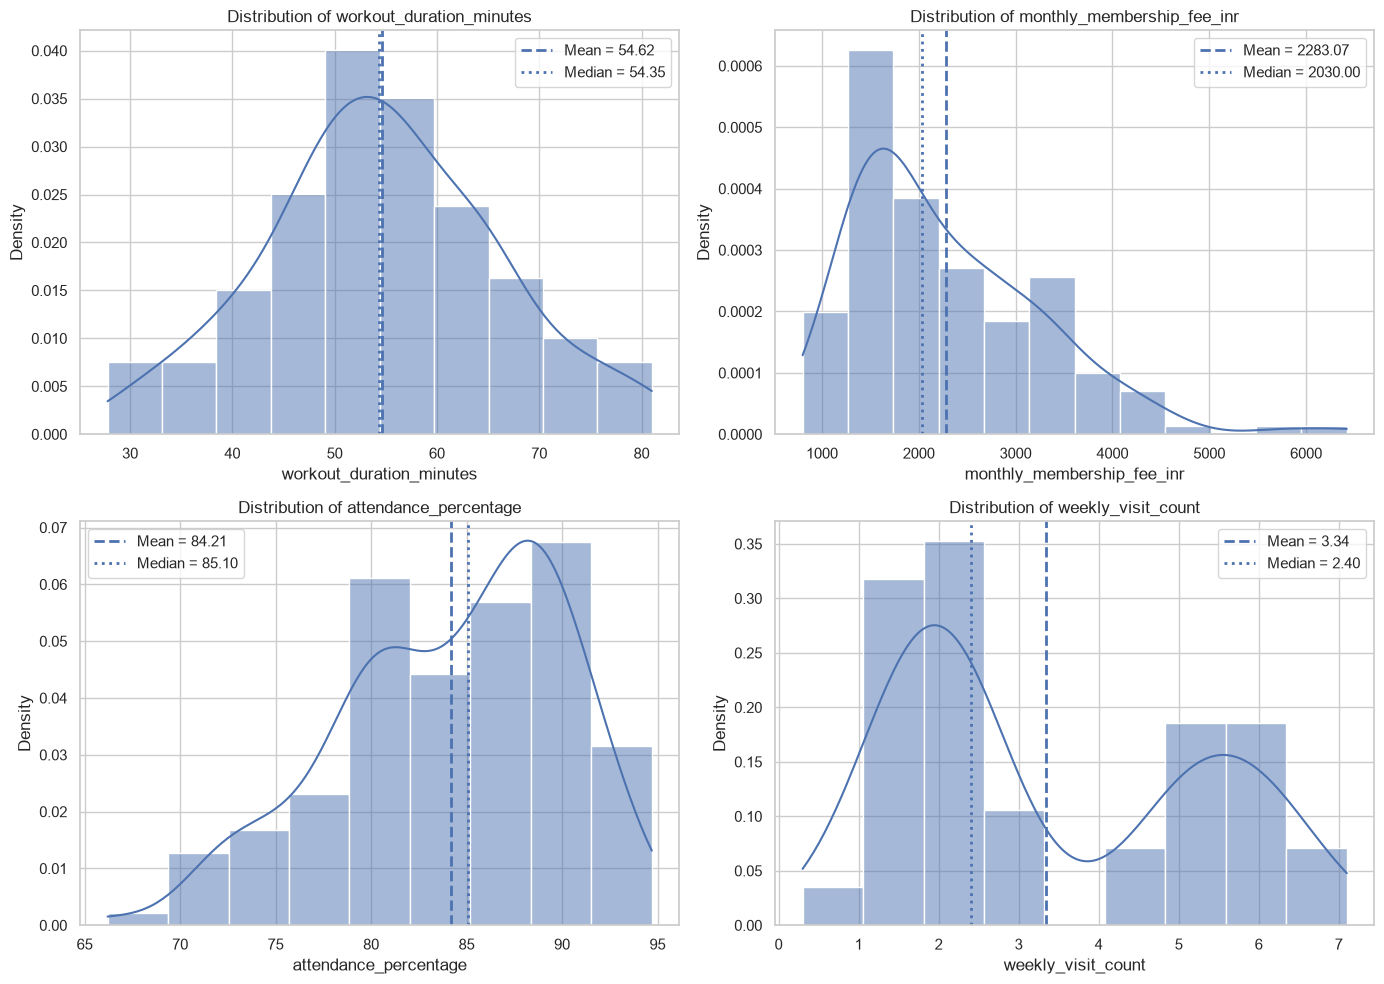

In [16]:
    # TODO: Q9 — 2x2 histogram grid with KDE, mean line, and median line per feature
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flat, FEATURES):

    # Histogram with KDE
    sns.histplot(
        df[feature],
        kde=True,
        stat="density",
        ax=ax
    )

    # Calculate mean and median
    mean_value = df[feature].mean()
    median_value = df[feature].median()

    # Mean line
    ax.axvline(
        mean_value,
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean_value:.2f}"
    )

    # Median line
    ax.axvline(
        median_value,
        linestyle=":",
        linewidth=2,
        label=f"Median = {median_value:.2f}"
    )
    
    # Title and labels
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Density")
    ax.legend()

plt.tight_layout()
plt.show()

### Q10 


The histogram confirms my prediction that weekly_visit_count is bimodal. It shows two distinct groups of gym members, with one group visiting around 1–2 times per week and another visiting around 5–6 times per week. The mean of 3.34 falls in the low-density valley between the two groups, so it is not a very sensible representation of a typical member.**Your answer:**

_(write here)_

### Q11  — Box plots

Standardize (z-score) the four numeric features — `z = (x - mean) / std` — and plot all four as **box plots side by side** on one figure, so their spreads are visually comparable despite being ondifferent original scales (₹, minutes, %, visits). Label the y-axis clearly. Briefly note in the plot title or a code comment which feature(s) show visible outlier points.

Standardized data:


,workout_duration_minutes,monthly_membership_fee_inr,attendance_percentage,weekly_visit_count
0,1.323,-0.602,-2.130,-1.080
1,2.315,0.170,0.339,-0.603
2,0.700,-0.094,0.815,0.935
3,0.972,0.901,-0.785,1.094
4,-0.467,-1.252,-0.598,-0.974


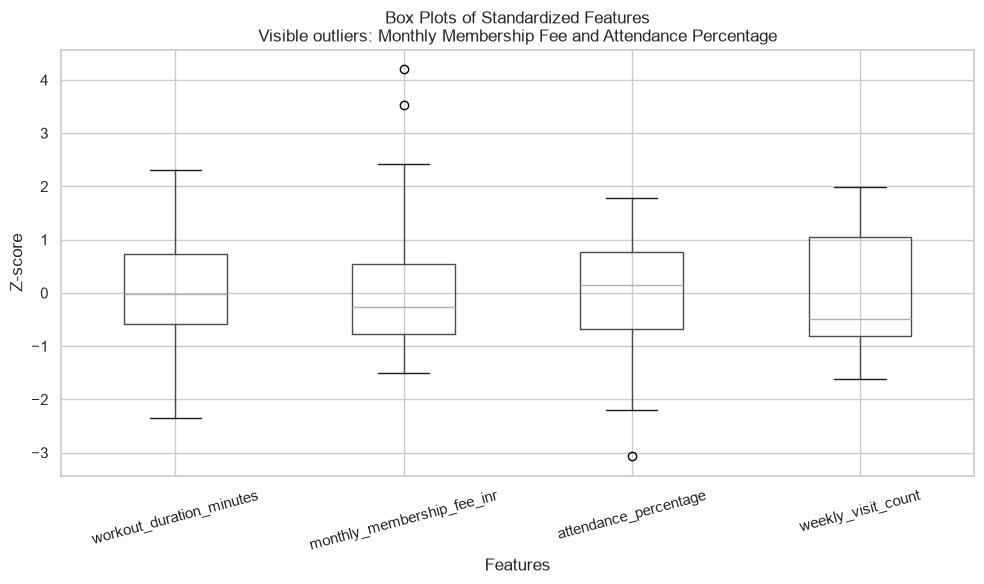

In [17]:
# TODO: Q11 — standardize all four features and plot them as side-by-side box plots
z_df = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std()

# Display the first few standardized values
print("Standardized data:")
display(z_df.head())

# Create side-by-side box plots
plt.figure(figsize=(10, 6))

z_df.boxplot()

plt.title(
    "Box Plots of Standardized Features\n"
    "Visible outliers: Monthly Membership Fee and Attendance Percentage"
)
plt.ylabel("Z-score")
plt.xlabel("Features")
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

### Q12 — Scatter plots

Choose **two pairs** of numeric features: one pair you hypothesize has a real relationship, and one
pair you hypothesize has little to no relationship. For each pair: compute the Pearson correlation
coefficient (`.corr()`), make a scatter plot, and put the correlation value in the plot title.

**Your answer (1–2 sentences per pair):** Did the scatter plots and correlation values support your
hypotheses? If a result surprised you, say so.

_(write here)_

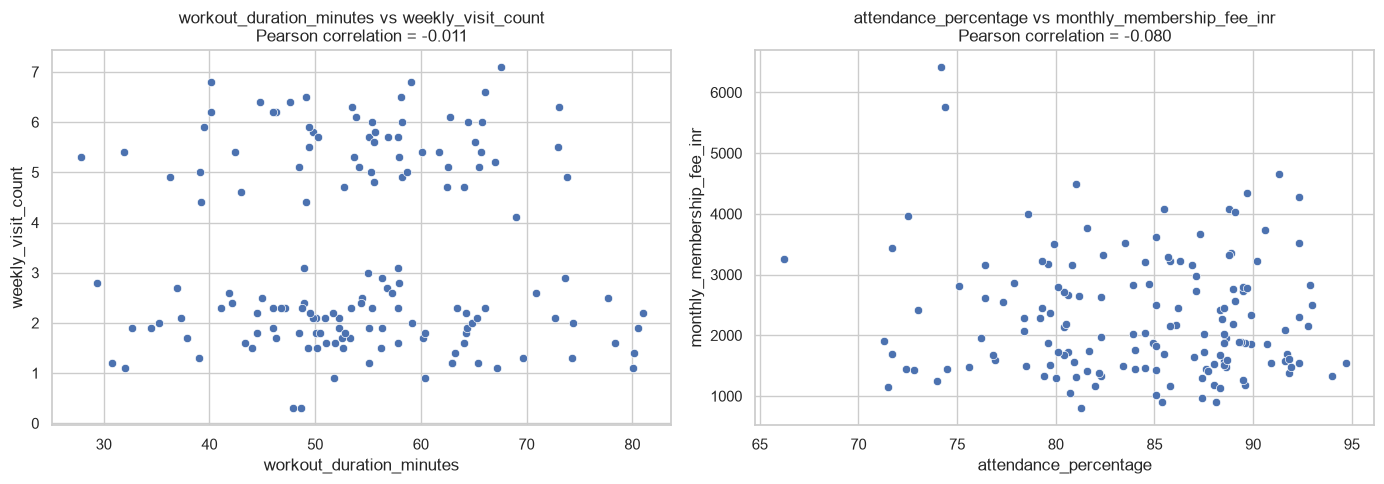

Correlation 1: -0.011220337579240307
Correlation 2: -0.07953740398016479


In [18]:
# TODO: Q12 — two scatter plots (one hypothesized relationship, one hypothesized no relationship)
x1 = "workout_duration_minutes"
y1 = "weekly_visit_count"

corr1 = df[x1].corr(df[y1])

# Pair 2: Hypothesized little/no relationship
x2 = "attendance_percentage"
y2 = "monthly_membership_fee_inr"

corr2 = df[x2].corr(df[y2])

# Create two scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot 1
sns.scatterplot(data=df, x=x1, y=y1, ax=axes[0])
axes[0].set_title(
    f"{x1} vs {y1}\nPearson correlation = {corr1:.3f}"
)
axes[0].set_xlabel(x1)
axes[0].set_ylabel(y1)

# Scatter plot 2
sns.scatterplot(data=df, x=x2, y=y2, ax=axes[1])
axes[1].set_title(
    f"{x2} vs {y2}\nPearson correlation = {corr2:.3f}"
)
axes[1].set_xlabel(x2)
axes[1].set_ylabel(y2)

plt.tight_layout()
plt.show()

# Print correlation values
print("Correlation 1:", corr1)
print("Correlation 2:", corr2)

## Part 6 — Synthesis

### Q13 

Build **one summary table** with a row per numeric feature and columns for: mean, median, standard
deviation, IQR, skewness, and excess kurtosis (you have already computed all of these in Q2, Q5–Q7
— this question is about assembling them, not recomputing from scratch).

Then write a short paragraph (roughly 100–150 words) that, **for each of the four features**,
recommends which central-tendency measure (mean or median) and which dispersion measure (standard
deviation or IQR) should be reported, and briefly justifies the choice using the specific evidence
in your own table (not general rules quoted from Lab 3).

In [23]:
# TODO: Q13 — assemble the comparative summary table
summary_table = pd.DataFrame(index=FEATURES)

# Mean and Median from Q2
summary_table["Mean"] = results["Mean"]
summary_table["Median"] = results["Median"]

# Standard deviation
summary_table["Standard Deviation"] = df[FEATURES].std()

# Use the manually calculated Q5 value for workout duration
summary_table.loc["workout_duration_minutes", "Standard Deviation"] = standard_deviation

# IQR from Q6
summary_table["IQR"] = iqr_table.set_index("Feature")["IQR"]

# Skewness and excess kurtosis from Q7
summary_table["Skewness"] = shape_table.set_index("Feature")["Skewness"]
summary_table["Excess Kurtosis"] = shape_table.set_index("Feature")["Excess Kurtosis"]

# Display the final table
display(summary_table.round(3))

,Mean,Median,Standard Deviation,IQR,Skewness,Excess Kurtosis
workout_duration_minutes,54.618,54.35,11.397,14.825,0.080,-0.194
monthly_membership_fee_inr,2283.067,2030.00,984.837,1310.000,1.165,1.761
attendance_percentage,84.210,85.10,5.874,8.600,-0.556,-0.353
weekly_visit_count,3.337,2.40,1.886,3.500,0.441,-1.369


**Your answer (recommendation paragraph):**

_(write here)_

For workout duration, I would report the mean and standard deviation because the mean (54.618) and median (54.35) are very close and the skewness (0.080) is near zero, indicating an approximately symmetric distribution. For monthly membership fee, I would report the median and IQR because the mean (2283.067) is noticeably higher than the median (2030), with strong right skewness (1.165) and two IQR outliers. For attendance percentage, the median and IQR are preferable because the mean (84.210) is lower than the median (85.10) and the skewness is negative (-0.556). For weekly visit count, I would also use the median and IQR, since the mean (3.337) is considerably higher than the median (2.40), the feature is right-skewed (0.441), and its histogram is bimodal.---

## Bonus (optional)

Group `df` by `preferred_workout` (`df.groupby("preferred_workout")`) and compare the mean
`attendance_percentage` across the four workout categories. Is attendance noticeably different for
any one category? Give one plausible real-world explanation for what you find (or for why there's
no real difference, if that's what you observe).

In [24]:
# TODO (bonus): groupby preferred_workout, compare mean attendance_percentage across categories

attendance_by_workout = (
    df.groupby("preferred_workout")["attendance_percentage"]
      .mean()
      .sort_values(ascending=False)
)

print("Mean attendance percentage by preferred workout:")
display(attendance_by_workout)



Mean attendance percentage by preferred workout:


preferred_workout
Weights     85.526
Yoga        84.029
Cardio      83.558
CrossFit    82.325
Name: attendance_percentage, dtype: float64

In [25]:
bonus_table = (
    df.groupby("preferred_workout")["attendance_percentage"]
      .mean()
      .reset_index()
      .rename(columns={"attendance_percentage": "Mean Attendance (%)"})
)

display(bonus_table)

,preferred_workout,Mean Attendance (%)
0,Cardio,83.558
1,CrossFit,82.325
2,Weights,85.526
3,Yoga,84.029


---

### Before you submit
- [ ] Ran the notebook top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every `# TODO` cell has working code, not just comments
- [ ] Every "Your answer" cell has a written response in your own words
- [ ] Did not modify the Part 1 dataset-generation code or the random seed